Implemented on Google colab

In [1]:
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from google.colab import drive
from google.colab.patches import cv2_imshow

In [2]:
# Select training device
if torch.cuda.is_available():
  device = torch.device("cuda")
  print(f"GPU name: {torch.cuda.get_device_name(0)}")
else:
  device = torch.device("cpu")

print(f"Using device: {device}")

GPU name: NVIDIA RTX PRO 6000 Blackwell Server Edition
Using device: cuda


In [3]:
import os, sys
print("Kernel alive")
print("cwd:", os.getcwd())
print("python:", sys.version)

Kernel alive
cwd: /content
python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


Mounted at /content/drive
Does training_data exist? True
Does validation_data exist? True
Does test_data exist? True
Training samples: 142
Validation samples: 24
Sample 0
Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([1, 256, 256])


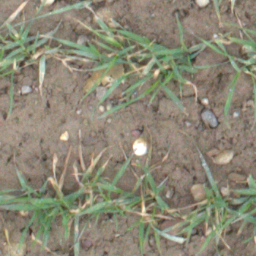

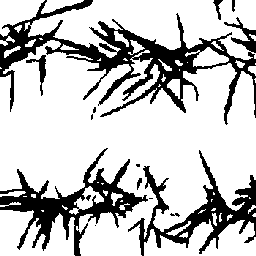

Sample 1
Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([1, 256, 256])


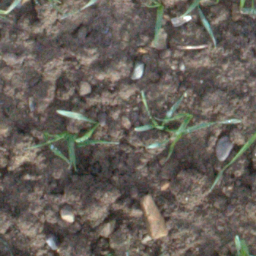

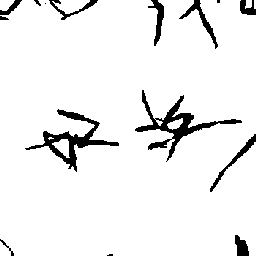

In [4]:
IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256
BATCH_SIZE = 4
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3

def load_and_resize_image(image_path, height, width, grayscale=False):
    flag = cv2.IMREAD_GRAYSCALE if grayscale else cv2.IMREAD_COLOR
    image = cv2.imread(str(image_path), flag)

    if image is None:
        raise ValueError(f"Could not load image: {image_path}")

    image = cv2.resize(image, (width, height), interpolation=cv2.INTER_NEAREST if grayscale else cv2.INTER_LINEAR)
    return image

drive.mount('/content/drive')

# Define the base dataset path
dataset_base_path = Path("/content/drive/MyDrive/COMP9517 assignment/EWS-Dataset")

# Define paths for training, validation, and test data
training_data = dataset_base_path / "train"
validation_data = dataset_base_path / "validation"
test_data = dataset_base_path / "test"

print(f"Does training_data exist? {training_data.exists()}")
print(f"Does validation_data exist? {validation_data.exists()}")
print(f"Does test_data exist? {test_data.exists()}")

class SegmentationDataset(Dataset):
    def __init__(self, folder_path, height, width):
        self.folder_path = Path(folder_path)
        self.height = height
        self.width = width

        # Input images are non-mask files; target masks end with _mask.png
        self.image_files = sorted([
            p for p in self.folder_path.iterdir()
            if p.is_file() and not p.name.endswith("_mask.png")
        ])

        self.mask_files = [self.folder_path / f"{image_path.stem}_mask.png" for image_path in self.image_files]

        missing_masks = [mask_path for mask_path in self.mask_files if not mask_path.exists()]
        if missing_masks:
            raise FileNotFoundError(f"Missing masks for {len(missing_masks)} images. Example: {missing_masks[0]}")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = self.image_files[idx]
        mask_path = self.mask_files[idx]

        image = load_and_resize_image(image_path, self.height, self.width, grayscale=False)
        mask = load_and_resize_image(mask_path, self.height, self.width, grayscale=True)

        # BGR -> RGB and normalize image to [0, 1]
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = image.astype(np.float32) / 255.0

        # Convert mask to binary float tensor of shape (1, H, W)
        mask = (mask > 127).astype(np.float32)

        image = torch.from_numpy(image).permute(2, 0, 1)   # (3, H, W)
        mask = torch.from_numpy(mask).unsqueeze(0)          # (1, H, W)

        return image, mask

train_dataset = SegmentationDataset(training_data, IMAGE_HEIGHT, IMAGE_WIDTH)
val_dataset = SegmentationDataset(validation_data, IMAGE_HEIGHT, IMAGE_WIDTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Display the first 2 image/mask pairs to verify loading
for i in range(min(2, len(train_dataset))):
    image_tensor, mask_tensor = train_dataset[i]

    image_to_show = (image_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    mask_to_show = (mask_tensor.squeeze(0).numpy() * 255).astype(np.uint8)

    print(f"Sample {i}")
    print("Image shape:", image_tensor.shape)
    print("Mask shape:", mask_tensor.shape)
    cv2_imshow(cv2.cvtColor(image_to_show, cv2.COLOR_RGB2BGR))
    cv2_imshow(mask_to_show)


In [5]:
# Define a simple encoder-decoder CNN for binary image segmentation
class SimpleSegmentationCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),   # (32, 128, 128)

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),   # (64, 64, 64)

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2)    # (128, 32, 32)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=2, stride=2),  # (64, 64, 64)
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=2, stride=2),   # (32, 128, 128)
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=2, stride=2),   # (16, 256, 256)
            nn.ReLU(inplace=True),

            nn.Conv2d(in_channels=16, out_channels=1, kernel_size=1)                         # (1, 256, 256)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

def dice_score_from_logits(logits, masks, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    intersection = (preds * masks).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + eps) / (union + eps)
    return dice.mean().item()

model = SimpleSegmentationCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)


SimpleSegmentationCNN(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
    (5): ReLU(inplace=True)
    (6): Conv2d(16, 1, kernel_size=(1, 1), stride=(1, 1))
  )
)


Epoch [1/10] | Train Loss: 0.6273 | Train Dice: 0.5511 | Val Loss: 0.5909 | Val Dice: 0.7835
Epoch [2/10] | Train Loss: 0.5151 | Train Dice: 0.8675 | Val Loss: 0.6024 | Val Dice: 0.7835
Epoch [3/10] | Train Loss: 0.5125 | Train Dice: 0.8670 | Val Loss: 0.6099 | Val Dice: 0.7835
Epoch [4/10] | Train Loss: 0.5001 | Train Dice: 0.8691 | Val Loss: 0.5737 | Val Dice: 0.7835
Epoch [5/10] | Train Loss: 0.4648 | Train Dice: 0.8700 | Val Loss: 0.5083 | Val Dice: 0.7836
Epoch [6/10] | Train Loss: 0.4090 | Train Dice: 0.8795 | Val Loss: 0.4052 | Val Dice: 0.8461
Epoch [7/10] | Train Loss: 0.3672 | Train Dice: 0.8977 | Val Loss: 0.4364 | Val Dice: 0.8543
Epoch [8/10] | Train Loss: 0.3510 | Train Dice: 0.8962 | Val Loss: 0.3525 | Val Dice: 0.8559
Epoch [9/10] | Train Loss: 0.3096 | Train Dice: 0.8947 | Val Loss: 0.3205 | Val Dice: 0.8225
Epoch [10/10] | Train Loss: 0.2852 | Train Dice: 0.9003 | Val Loss: 0.2990 | Val Dice: 0.8631
Validation sample 0
Input image


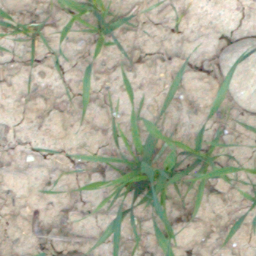

Ground-truth mask


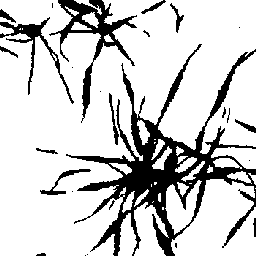

Predicted mask


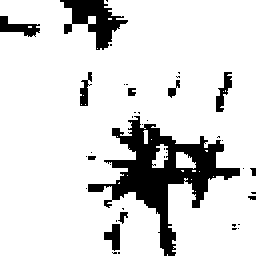

Validation sample 1
Input image


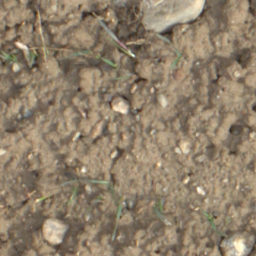

Ground-truth mask


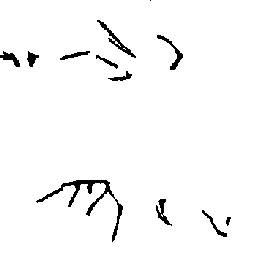

Predicted mask


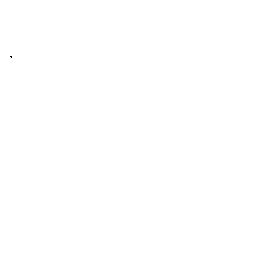

In [6]:
# Training and validation loop
for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0
    train_dice = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_score_from_logits(logits.detach(), masks)

    avg_train_loss = train_loss / len(train_loader)
    avg_train_dice = train_dice / len(train_loader)

    model.eval()
    val_loss = 0.0
    val_dice = 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            loss = criterion(logits, masks)

            val_loss += loss.item()
            val_dice += dice_score_from_logits(logits, masks)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_dice = val_dice / len(val_loader)

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"Train Loss: {avg_train_loss:.4f} | Train Dice: {avg_train_dice:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | Val Dice: {avg_val_dice:.4f}"
    )

# Show a few validation predictions
model.eval()
with torch.no_grad():
    images, masks = next(iter(val_loader))
    images = images.to(device)
    masks = masks.to(device)

    logits = model(images)
    preds = (torch.sigmoid(logits) > 0.5).float()

for i in range(min(2, images.size(0))):
    image_to_show = (images[i].detach().cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    mask_to_show = (masks[i].detach().cpu().squeeze(0).numpy() * 255).astype(np.uint8)
    pred_to_show = (preds[i].detach().cpu().squeeze(0).numpy() * 255).astype(np.uint8)

    print(f"Validation sample {i}")
    print("Input image")
    cv2_imshow(cv2.cvtColor(image_to_show, cv2.COLOR_RGB2BGR))
    print("Ground-truth mask")
    cv2_imshow(mask_to_show)
    print("Predicted mask")
    cv2_imshow(pred_to_show)


Test samples: 24

Test Loss: 0.3207
Test Dice Score: 0.8750

Test sample 1
Input image


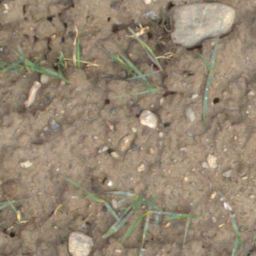

Ground-truth mask


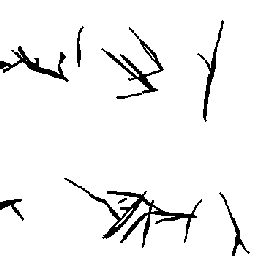

Predicted mask


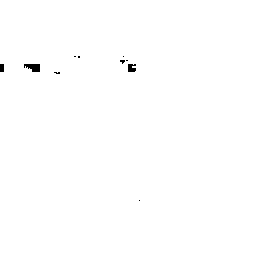


Test sample 2
Input image


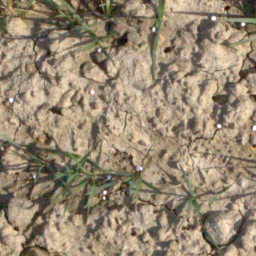

Ground-truth mask


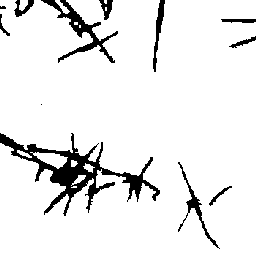

Predicted mask


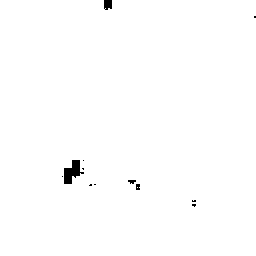


Test sample 3
Input image


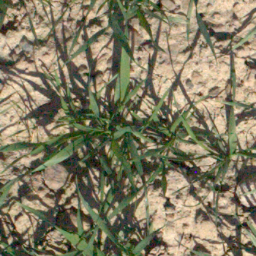

Ground-truth mask


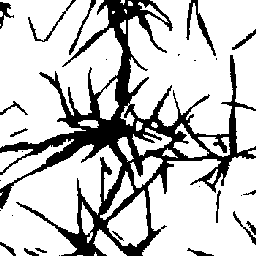

Predicted mask


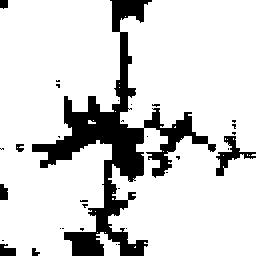

In [7]:
# Test set evaluation + display predictions

# Create test dataset and loader
test_dataset = SegmentationDataset(test_data, IMAGE_HEIGHT, IMAGE_WIDTH)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Test samples: {len(test_dataset)}")

model.eval()
test_loss = 0.0
test_dice = 0.0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks)

        test_loss += loss.item()
        test_dice += dice_score_from_logits(logits, masks)

avg_test_loss = test_loss / len(test_loader)
avg_test_dice = test_dice / len(test_loader)

print(f"\nTest Loss: {avg_test_loss:.4f}")
print(f"Test Dice Score: {avg_test_dice:.4f}")


# Display a few test predictions
num_samples_to_show = 3

model.eval()
shown = 0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        for i in range(images.size(0)):
            if shown >= num_samples_to_show:
                break

            image_to_show = (images[i].cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            mask_to_show = (masks[i].cpu().squeeze(0).numpy() * 255).astype(np.uint8)
            pred_to_show = (preds[i].cpu().squeeze(0).numpy() * 255).astype(np.uint8)

            print(f"\nTest sample {shown + 1}")
            print("Input image")
            cv2_imshow(cv2.cvtColor(image_to_show, cv2.COLOR_RGB2BGR))

            print("Ground-truth mask")
            cv2_imshow(mask_to_show)

            print("Predicted mask")
            cv2_imshow(pred_to_show)

            shown += 1

        if shown >= num_samples_to_show:
            break